In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [11]:
X_test = np.load("X_test.npy")
Y_test = np.load("y_test.npy")

if Y_test.ndim == 1:
    Y_test = Y_test.reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).to(device)

print("X_test:", X_test_tensor.shape)
print("Y_test:", Y_test_tensor.shape)


X_test: torch.Size([14356, 24, 1])
Y_test: torch.Size([14356, 1])


In [12]:
##### LSTM regressor
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, timesteps, features)
        out, _ = self.lstm(x) # out: (batch, timesteps, hidden)
        out = out[:, -1, :] # last timestep: (batch, hidden)
        out = self.drop(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out) # (batch, 1)
        return out

In [13]:
##### 1D CNN regressors
class CNN1DRegressor(nn.Module):
    def __init__(self, in_channels, dropout):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=3, padding=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # infer flatten size using a dummy forward
        self._fc1 = None
        self.fc2 = nn.Linear(32, 1)

    def _build_fc(self, x_shape):
        # x: (batch, timesteps, features) -> becomes (batch, features, timesteps)
        with torch.no_grad():
            dummy = torch.zeros(x_shape, dtype=torch.float32)
            dummy = dummy.permute(0, 2, 1)  # (B, F, T)
            z = self.pool(self.relu(self.conv1(dummy)))
            z = self.pool(self.relu(self.conv2(z)))
            z = torch.flatten(z, start_dim=1)
            self._fc1 = nn.Linear(z.shape[1], 32)

    def forward(self, x):
        # x: (batch, timesteps, features)
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.drop(x)
        x = torch.flatten(x, start_dim=1)
        x = self.relu(self._fc1(x))
        x = self.fc2(x)
        return x

In [14]:
# infer shapes
timesteps = X_test.shape[1]
features = X_test.shape[2]

lstm_model = LSTMRegressor( #Lstm
    input_size=features,
    hidden_size=64,
    dropout=0.2
).to(device)

#cnn
cnn_model = CNN1DRegressor(
    in_channels=features,
    dropout=0.2
).to(device)

cnn_model._build_fc((1, timesteps, features))


In [15]:
lstm_model.load_state_dict(torch.load("best_LSTM.pt", map_location=device))
cnn_model.load_state_dict(torch.load("best_CNN.pt", map_location=device))

lstm_model.eval()
cnn_model.eval()


CNN1DRegressor(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(2,))
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (_fc1): Linear(in_features=448, out_features=32, bias=True)
)

In [16]:
with torch.no_grad():
    lstm_preds = lstm_model(X_test_tensor)
    cnn_preds = cnn_model(X_test_tensor)

lstm_preds = lstm_preds.cpu().numpy().flatten()
cnn_preds = cnn_preds.cpu().numpy().flatten()
y_true = Y_test.flatten()


In [17]:
lstm_diff = y_true - lstm_preds
cnn_diff = y_true - cnn_preds


In [18]:
print("LSTM MAE :", np.mean(np.abs(lstm_diff)))
print("CNN  MAE :", np.mean(np.abs(cnn_diff)))

print("LSTM RMSE:", np.sqrt(np.mean(lstm_diff**2)))
print("CNN  RMSE:", np.sqrt(np.mean(cnn_diff**2)))


LSTM MAE : 0.02846187599166562
CNN  MAE : 0.02996343751701679
LSTM RMSE: 0.03936923381457874
CNN  RMSE: 0.04137421476579392


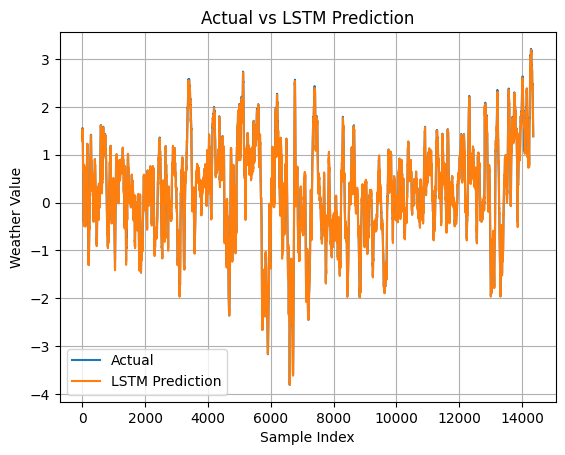

In [19]:
#Plotting starts here
plt.figure()
plt.plot(y_true, label="Actual")
plt.plot(lstm_preds, label="LSTM Prediction")
plt.title("Actual vs LSTM Prediction")
plt.xlabel("Sample Index")
plt.ylabel("Weather Value")
plt.legend()
plt.grid(True)
plt.show()


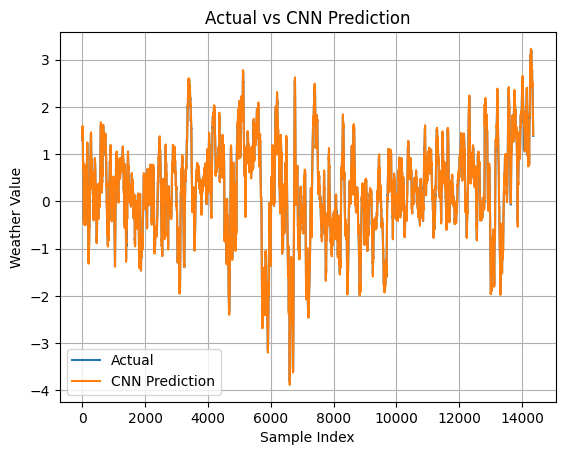

In [20]:
plt.figure()
plt.plot(y_true, label="Actual")
plt.plot(cnn_preds, label="CNN Prediction")
plt.title("Actual vs CNN Prediction")
plt.xlabel("Sample Index")
plt.ylabel("Weather Value")
plt.legend()
plt.grid(True)
plt.show()


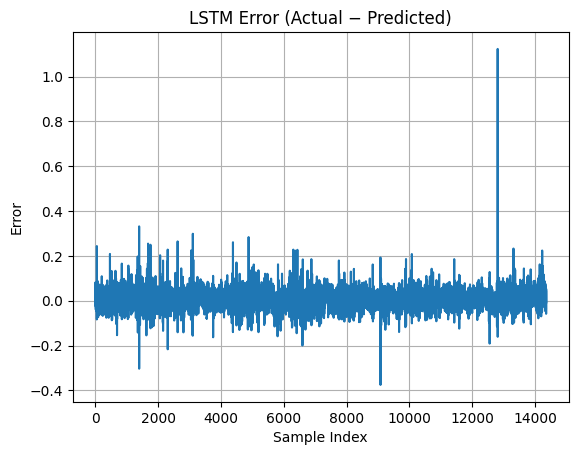

In [21]:
plt.figure()
plt.plot(lstm_diff)
plt.title("LSTM Error (Actual − Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.grid(True)
plt.show()


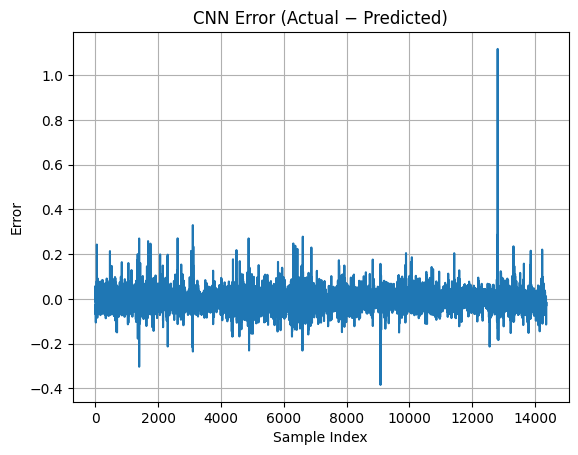

In [22]:
plt.figure()
plt.plot(cnn_diff)
plt.title("CNN Error (Actual − Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.grid(True)
plt.show()


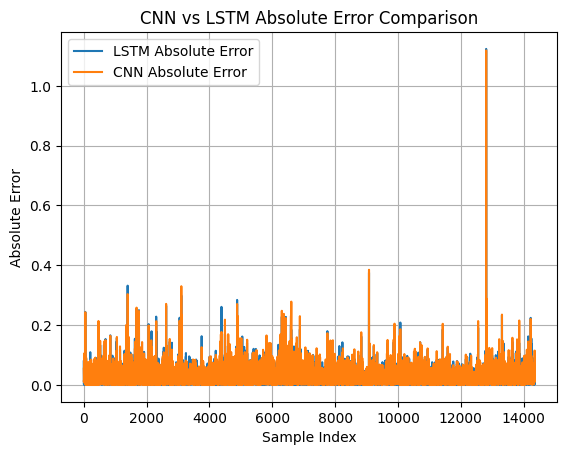

In [23]:
plt.figure()
plt.plot(np.abs(lstm_diff), label="LSTM Absolute Error")
plt.plot(np.abs(cnn_diff), label="CNN Absolute Error")
plt.title("CNN vs LSTM Absolute Error Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)
plt.show()


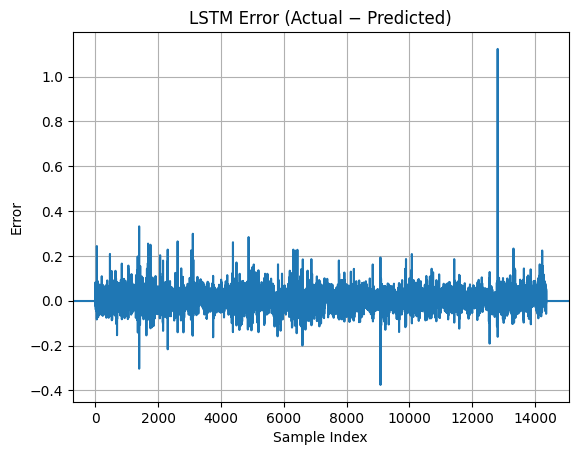

In [24]:
plt.figure()
plt.plot(lstm_diff)
plt.axhline(0)
plt.title("LSTM Error (Actual − Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.grid(True)
plt.show()


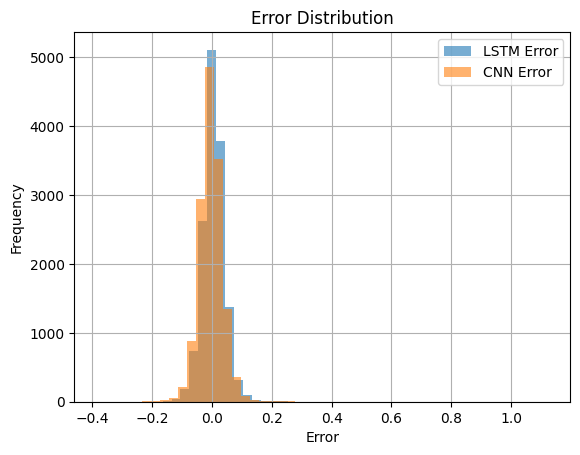

In [25]:
plt.figure()
plt.hist(lstm_diff, bins=50, alpha=0.6, label="LSTM Error")
plt.hist(cnn_diff, bins=50, alpha=0.6, label="CNN Error")
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
# ==========================================
# PASTE THIS AT THE END OF YOUR NOTEBOOK
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: GET THE REAL VALUES (DE-NORMALIZATION)
# We need the original Mean and Std Dev to convert back to °C
# ---------------------------------------------------------
print("Recalculating scaler statistics to get real °C values...")

# Load data just to get statistics
df_temp = pd.read_csv("jena_climate_2009_2016.csv")
df_temp = df_temp[5::6] # Subsample hourly
data_temp = df_temp.iloc[:, 1:].values.astype(float) # Drop Date Time

# We must use the SAME training split to calculate mean/std
train_split = int(0.7 * len(data_temp))
train_data = data_temp[:train_split]

# Calculate Mean and Std for the Target Column (Index 1 = T degC)
# Index 0 is Pressure, Index 1 is Temperature
T_mean = train_data[:, 1].mean()
T_std = train_data[:, 1].std()

print(f"Recovered Stats -> Mean Temp: {T_mean:.2f}°C, Std Dev: {T_std:.2f}°C")



Recalculating scaler statistics to get real °C values...
Recovered Stats -> Mean Temp: 9.11°C, Std Dev: 8.65°C


In [34]:
# ---------------------------------------------------------
# STEP 2: CONVERT PREDICTIONS TO CELSIUS
# ---------------------------------------------------------
# Ensure predictions are flat numpy arrays
# (Assuming lstm_preds, cnn_preds, and y_true exist from your previous model run)
lstm_real = (lstm_preds * T_std) + T_mean
cnn_real = (cnn_preds * T_std) + T_mean
y_real = (y_true * T_std) + T_mean


In [35]:
# ---------------------------------------------------------
# STEP 3: SHOW PREDICTIONS (TEXT/TABLE FORMAT)
# ---------------------------------------------------------
print("\n" + "="*50)
print("REAL VALUE PREDICTIONS (Last 10 Hours)")
print("="*50)
print(f"{'Hour':<10} | {'Actual (°C)':<15} | {'LSTM Pred (°C)':<15} | {'CNN Pred (°C)':<15}")
print("-" * 65)

# Show the last 10 predictions
for i in range(10):
    idx = -10 + i # Last 10 indices
    print(f"{i:<10} | {y_real[idx]:<15.2f} | {lstm_real[idx]:<15.2f} | {cnn_real[idx]:<15.2f}")
    print("-" * 65)

# Calculate Real MAE
lstm_mae_real = np.mean(np.abs(y_real - lstm_real))
cnn_mae_real = np.mean(np.abs(y_real - cnn_real))
print(f"\nFinal Accuracy (Mean Absolute Error):")
print(f"LSTM Error: +/- {lstm_mae_real:.2f} °C")
print(f"CNN Error : +/- {cnn_mae_real:.2f} °C")


REAL VALUE PREDICTIONS (Last 10 Hours)
Hour       | Actual (°C)     | LSTM Pred (°C)  | CNN Pred (°C)  
-----------------------------------------------------------------
0          | 24.36           | 24.36           | 24.61          
-----------------------------------------------------------------
1          | 24.19           | 23.94           | 24.10          
-----------------------------------------------------------------
2          | 23.62           | 23.95           | 24.05          
-----------------------------------------------------------------
3          | 23.50           | 23.11           | 23.65          
-----------------------------------------------------------------
4          | 23.34           | 23.22           | 23.61          
-----------------------------------------------------------------
5          | 23.24           | 23.01           | 23.55          
-----------------------------------------------------------------
6          | 22.43           | 22.93       

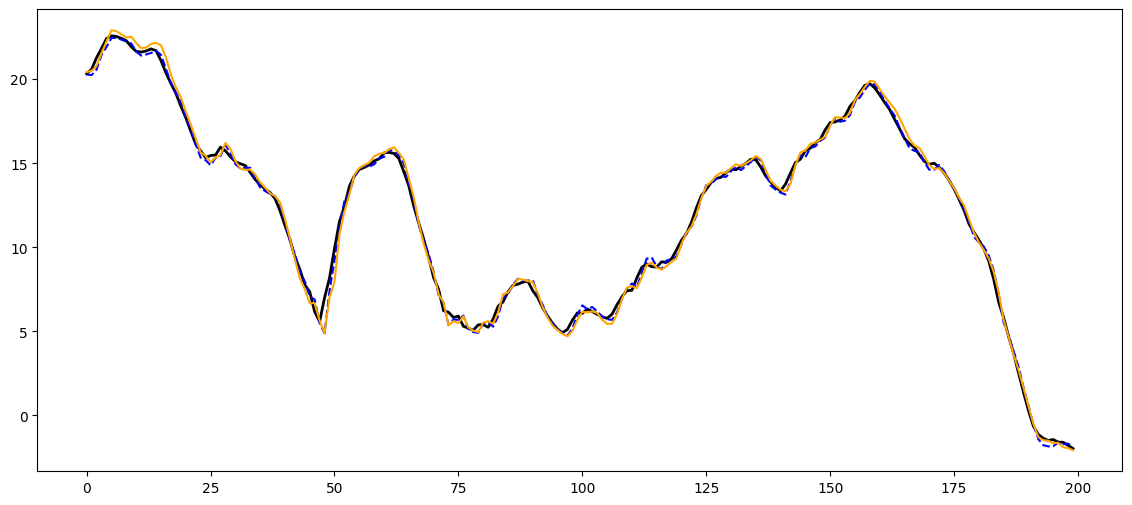

In [36]:
# ---------------------------------------------------------
# STEP 4: PLOTTING THE GRAPHS
# ---------------------------------------------------------
# Plot 1: The Timeline (Zoomed in to see details)
plt.figure(figsize=(14, 6))
# We plot only the first 200 hours of the test set for clarity
subset = 200 
plt.plot(y_real[:subset], label="Actual Temperature", color='black', linewidth=2)
plt.plot(lstm_real[:subset], label="LSTM Prediction", color='blue', linestyle='--')
plt.plot(cnn_real[:subset], label="CNN Prediction", color='orange')